# 12주차: PCA(주성분 분석) — 차원축소의 원리와 실습
### 📊 데이터: sklearn breast_cancer → 11주차와 동일 569명 × 30개 피처 — 30차원을 2차원으로 요약
---
## 차시 1 (개념 — 코드 없음)
- **차원축소 필요성 3가지**: 시각화(30d→2d) / 노이즈 제거(신호 보존) / 차원의 저주 완화(데이터 밀집화)
- **차원의 저주**: 차원↑ → 데이터 희소 → 거리 무의미 → K-Means·k-NN 성능↓
- **PCA 핵심 원리**: 「분산을 최대화하는 새로운 축(주성분)을 찾는다」= 정보를 최대한 보존하는 방향
- **주성분(PC)**: PC1=분산 최대 방향, PC2=PC1과 직교하면서 분산 최대, 각 PC=기존 피처의 선형 결합(가중합)
- **PCA ≠ 피처 선택**: 피처 선택=기존 피처를 골라냄 / PCA=기존 피처를 **조합**하여 새 축 생성
- **스케일링 필수**: PCA=분산 기반 → 스케일링 없으면 단위 큰 피처(area)가 PC1 지배

## 차시 2
- **PCA 적용**: `PCA(n_components=2).fit_transform(X_scaled)` → (569, 30) → (569, 2)
- **설명된 분산 비율**: `explained_variance_ratio_` — PC1: ~44%, PC1+PC2: ~63%
- **주성분 수 선택**: 누적 분산 90%→7개 / 95%→10개 / 시각화→2개 — K 선택처럼 판단
- **2차원 시각화**: PCA 산점도에서 양성/악성 분리 확인 — 30차원의 구조를 눈으로
- **K-Means + PCA**: K-Means 클러스터를 PCA 2차원에 색으로 표시 → 비지도학습 결합

## 차시 3
- **Pipeline + PCA**: StandardScaler → PCA → LogisticRegression — 10주차 Pipeline 확장
- **교차검증 비교**: PCA 없음 ~97% / PCA(7) ~96.5% / PCA(2) ~95.5% — PCA가 항상 성능↑은 아님
- **PCA의 실용적 가치**: 「항상 성능 향상」이 아닌 「적은 차원으로 비슷한 성능」+ 시각화 + 노이즈 제거
- **맹목적 적용 금지**: PCA를 쓸지 말지는 실험으로 확인 — 교차검증이 판단의 근거

---
## Step 1. 라이브러리 임포트

In [1]:
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA              # ← 오늘의 핵심!
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"Python: {sys.version.split()[0]}")

scikit-learn: 1.6.1
Python: 3.12.12


---
## Step 2. 데이터 로드 및 탐색
- **데이터**: sklearn 내장 `breast_cancer` — 11주차 K-Means와 동일
- **피처 (30개)**: 종양의 반지름·둘레·넓이 등 세포핵 측정값 (mean / se / worst)
- **타겟**: 양성(1) / 악성(0) — PCA에서는 사용하지 않음, 차시 3에서 지도학습 결합 시 사용
- **샘플 수**: 569개

**⚠ PCA는 비지도학습 — fit(X)에서 X만 넣는다. y는 결과 확인용·차시 3 지도학습용**

In [2]:
data = load_breast_cancer()
X = data.data
y = data.target             # ⚠ PCA에는 사용 안 함 — 확인용/차시3 지도학습용
feature_names = data.feature_names

print(f"피처 수  : {X.shape[1]}")
print(f"샘플 수  : {X.shape[0]}")
print(f"피처 이름(처음 5개): {list(feature_names[:5])}")
print(f"타겟 클래스: {list(data.target_names)}")
print(f"타겟 분포 : 양성(1)={np.sum(y == 1)}명, 악성(0)={np.sum(y == 0)}명")
print()
print("→ 11주차와 같은 데이터 — K-Means에 이어 PCA를 적용한다")
print("→ y는 PCA에 사용하지 않는다 (비지도학습)")

피처 수  : 30
샘플 수  : 569
피처 이름(처음 5개): [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness')]
타겟 클래스: [np.str_('malignant'), np.str_('benign')]
타겟 분포 : 양성(1)=357명, 악성(0)=212명

→ 11주차와 같은 데이터 — K-Means에 이어 PCA를 적용한다
→ y는 PCA에 사용하지 않는다 (비지도학습)


---
## Step 3. 스케일링 — PCA는 분산 기반이므로 필수

PCA는 **분산(variance)** 을 기준으로 주성분을 찾습니다.
피처의 단위·범위가 다르면 분산이 왜곡되어 단위가 큰 피처가 PC1을 **지배**합니다.

| K-Means (11주차) | PCA (12주차) |
|:-:|:-:|
| **거리** 기반 → 스케일링 필수 | **분산** 기반 → 스케일링 필수 |

→ **비지도학습 공통 원칙**: `StandardScaler` 먼저!

| 비유 | 스케일링 없이 PCA하면 area(143~2501)가 PC1을 독점 → 피처 조합이 아닌 피처 선택이 되어버림 |

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("=== 스케일링 전후 비교 ===")
print(
    f"스케일링 전 — mean radius  범위: "
    f"{X[:, 0].min():.1f} ~ {X[:, 0].max():.1f}"
)
print(
    f"스케일링 전 — mean area    범위: "
    f"{X[:, 3].min():.1f} ~ {X[:, 3].max():.1f}"
)
print(
    f"스케일링 후 — 평균: {X_scaled.mean():.4f}, "
    f"표준편차: {X_scaled.std():.4f}"
)
print()
print("→ 스케일링 후 평균 ≈ 0, 표준편차 ≈ 1 확인")
print("→ PCA는 분산 기반 — 스케일링 없으면 area가 PC1을 지배한다")

=== 스케일링 전후 비교 ===
스케일링 전 — mean radius  범위: 7.0 ~ 28.1
스케일링 전 — mean area    범위: 143.5 ~ 2501.0
스케일링 후 — 평균: -0.0000, 표준편차: 1.0000

→ 스케일링 후 평균 ≈ 0, 표준편차 ≈ 1 확인
→ PCA는 분산 기반 — 스케일링 없으면 area가 PC1을 지배한다


---
## Step 4. PCA 적용 — 전체 주성분(30개)으로 계산
- `n_components` 미지정 → 전체 주성분을 모두 계산
- 각 주성분이 얼마나 중요한지 확인한 **후** 몇 개를 남길지 결정하기 위해
- `fit`: PCA가 분산이 가장 큰 축들을 계산
- `transform`: 데이터를 그 축들에 투영

| 비유 | 30명이 말하는 회의에서 목소리 크기순으로 정렬 — 전체를 먼저 듣고, 상위 몇 명만 남길지 결정 |

In [4]:
pca_full = PCA()                # n_components 미지정 → 전체 주성분
X_pca_full = pca_full.fit_transform(X_scaled)

print(f"PCA 변환 후 shape: {X_pca_full.shape}")    # (569, 30)
print(f"주성분 수: {pca_full.n_components_}")       # 30
print()
print("→ 30개 주성분을 전부 계산 — 아직 차원을 줄인 것이 아님")
print("→ 각 주성분의 중요도를 확인한 후 몇 개를 남길지 결정한다")

PCA 변환 후 shape: (569, 30)
주성분 수: 30

→ 30개 주성분을 전부 계산 — 아직 차원을 줄인 것이 아님
→ 각 주성분의 중요도를 확인한 후 몇 개를 남길지 결정한다


---
## Step 5. 설명된 분산 비율 — 각 주성분이 전체 분산의 몇 %?

`explained_variance_ratio_`: 각 주성분이 전체 정보 중 몇 %를 담당하는지

| 주성분 | 설명 분산 | 의미 |
|:-:|:-:|:--|
| PC1 | ~44% | 30개 피처 정보 중 44%가 PC1 **하나**에 압축 |
| PC1+PC2 | ~63% | 2개 주성분으로 63% 보존 → 시각화 가능 |
| 상위 5개 | ~85% | 나머지 25개는 합쳐서 15% — 대부분 노이즈 |
| 전체 합 | 100% | 모든 주성분 사용 → 원래 데이터와 정보 동일 |

In [5]:
evr = pca_full.explained_variance_ratio_

print("=== 각 주성분의 설명된 분산 비율 ===")
print(f"{'PC':<6} {'비율':>8} {'%':>8}  시각화")
print("-" * 50)
for i in range(min(10, len(evr))):
    bar = "█" * int(evr[i] * 100)
    print(f"  PC{i + 1:<2d} {evr[i]:>8.4f} {evr[i] * 100:>7.1f}%  {bar}")
print("  ... (이하 PC11~PC30 생략)")
print()
print(f"상위  2개 합계: {sum(evr[:2]):.4f} ({sum(evr[:2]) * 100:.1f}%)")
print(f"상위  5개 합계: {sum(evr[:5]):.4f} ({sum(evr[:5]) * 100:.1f}%)")
print(f"상위  7개 합계: {sum(evr[:7]):.4f} ({sum(evr[:7]) * 100:.1f}%)")
print(f"상위 10개 합계: {sum(evr[:10]):.4f} ({sum(evr[:10]) * 100:.1f}%)")
print(f"전체   합계:   {sum(evr):.4f} ({sum(evr) * 100:.1f}%)")

=== 각 주성분의 설명된 분산 비율 ===
PC           비율        %  시각화
--------------------------------------------------
  PC1    0.4427    44.3%  ████████████████████████████████████████████
  PC2    0.1897    19.0%  ██████████████████
  PC3    0.0939     9.4%  █████████
  PC4    0.0660     6.6%  ██████
  PC5    0.0550     5.5%  █████
  PC6    0.0402     4.0%  ████
  PC7    0.0225     2.3%  ██
  PC8    0.0159     1.6%  █
  PC9    0.0139     1.4%  █
  PC10   0.0117     1.2%  █
  ... (이하 PC11~PC30 생략)

상위  2개 합계: 0.6324 (63.2%)
상위  5개 합계: 0.8473 (84.7%)
상위  7개 합계: 0.9101 (91.0%)
상위 10개 합계: 0.9516 (95.2%)
전체   합계:   1.0000 (100.0%)


---
## Step 6. 누적 설명 분산 — K개 주성분까지 쓰면 몇 %를 보존하는가?

`np.cumsum(evr)`: 배열의 누적 합계 — PC1부터 PCn까지의 합을 순서대로 계산

### 핵심 수치
| 주성분 수 | 누적 분산 | 의미 |
|:-:|:-:|:--|
| 7개 | ~91% | 30d→7d (차원 77% 감소) + 정보 91% 보존 — **90% 기준 통과** |
| 10개 | ~95% | 30d→10d (차원 67% 감소) + 정보 95% 보존 — **95% 기준 통과** |
| 2개 | ~63% | 37% 손실이지만 2차원 시각화 가능 — 「보이는 것」의 가치 |

In [6]:
cumulative_evr = np.cumsum(evr)   # 누적합

print("=== 누적 설명된 분산 ===")
print(f"{'범위':<12} {'누적 비율':>10} {'%':>8}")
print("-" * 35)
for i in [0, 1, 2, 4, 6, 9, 14, 29]:
    marker = ""
    if i == 6:
        marker = "  ← 90% 기준"
    elif i == 9:
        marker = "  ← 95% 기준"
    print(
        f"  PC1~PC{i + 1:<2d} {cumulative_evr[i]:>10.4f}"
        f" {cumulative_evr[i] * 100:>7.1f}%{marker}"
    )

print()
print("→ 7개 주성분이면 91% 보존 — 차원을 77% 줄이면서 정보 대부분 유지")
print("→ 숫자만으로 판단 어렵다 → 그래프로!")

=== 누적 설명된 분산 ===
범위                누적 비율        %
-----------------------------------
  PC1~PC1      0.4427    44.3%
  PC1~PC2      0.6324    63.2%
  PC1~PC3      0.7264    72.6%
  PC1~PC5      0.8473    84.7%
  PC1~PC7      0.9101    91.0%  ← 90% 기준
  PC1~PC10     0.9516    95.2%  ← 95% 기준
  PC1~PC15     0.9865    98.6%
  PC1~PC30     1.0000   100.0%

→ 7개 주성분이면 91% 보존 — 차원을 77% 줄이면서 정보 대부분 유지
→ 숫자만으로 판단 어렵다 → 그래프로!


---
## Step 7. 개별 + 누적 분산 그래프 — 나란히 시각화
- **왼쪽 막대 그래프**: 각 주성분의 설명 분산 — PC1 압도적, PC3 이후 급감, PC10 이후 거의 0
- **오른쪽 누적 곡선**: 90%(초록)·95%(주황) 기준선 — 몇 번째 주성분에서 넘는지 확인

### 그래프 해석 포인트
| 그래프 | 확인할 것 | 의미 |
|--------|----------|------|
| 개별 (왼쪽) | PC1의 압도적 높이 | 주요 정보가 앞쪽 주성분에 집중 |
| 누적 (오른쪽) | 기준선 통과 지점 | 90%→7개, 95%→10개 |

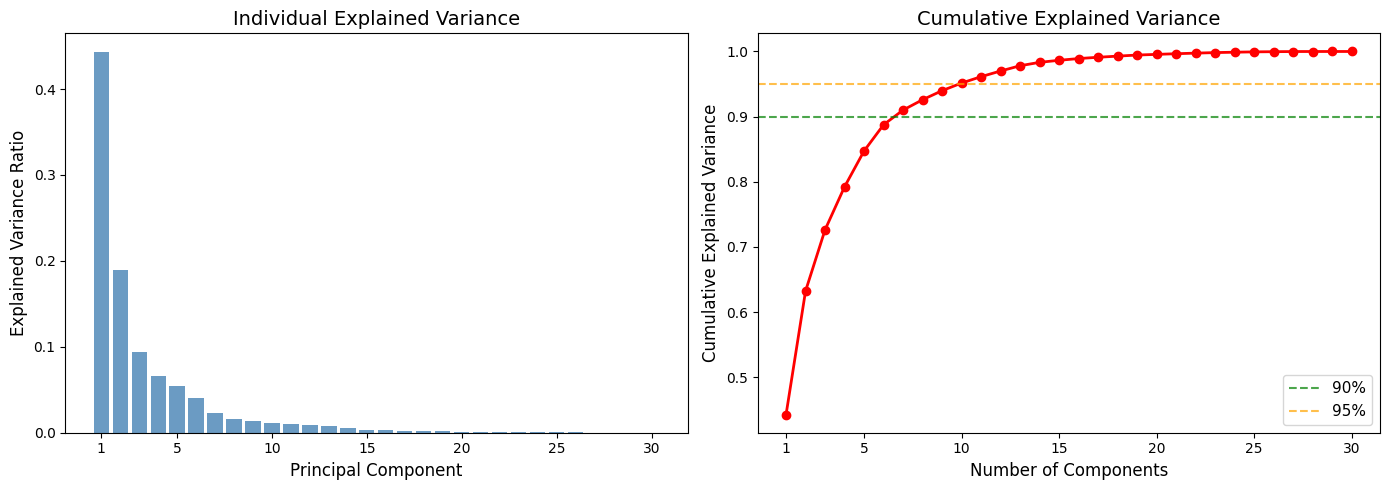

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: 개별 설명 분산
axes[0].bar(range(1, 31), evr, color="steelblue", alpha=0.8)
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Explained Variance Ratio", fontsize=12)
axes[0].set_title("Individual Explained Variance", fontsize=14)
axes[0].set_xticks([1, 5, 10, 15, 20, 25, 30])

# 오른쪽: 누적 설명 분산
axes[1].plot(range(1, 31), cumulative_evr, "ro-", linewidth=2, markersize=6)
axes[1].axhline(y=0.90, color="green", linestyle="--", alpha=0.7, label="90%")
axes[1].axhline(y=0.95, color="orange", linestyle="--", alpha=0.7, label="95%")
axes[1].set_xlabel("Number of Components", fontsize=12)
axes[1].set_ylabel("Cumulative Explained Variance", fontsize=12)
axes[1].set_title("Cumulative Explained Variance", fontsize=14)
axes[1].set_xticks([1, 5, 10, 15, 20, 25, 30])
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Step 8. 주성분 수 선택 — 활용 목적에 따른 판단

11주차 K 선택처럼 **정답은 없고** 활용 목적에 따른 판단이 필요하다

| 기준 | 주성분 수 | 설명 |
|------|:-:|------|
| 누적 분산 90% | 7개 | 가장 널리 사용. 노이즈 제거 목적 |
| 누적 분산 95% | 10개 | 정보 우선 목적 |
| 시각화 목적 | 2개 | 2차원 산점도. 63% 보존이지만 「보이는 것」의 가치 |
| 자동 선택 | `PCA(n_components=0.95)` | 실수를 넣으면 최소 개수를 자동 결정 |

→ 11주차 K 선택 = 12주차 n_components 선택 — 둘 다 「정답이 아니라 판단」

**⚠ 지표는 참고이고 결정은 활용 목적에 달려 있다**

In [8]:
# n_components에 실수를 넣으면 자동 선택
pca_auto = PCA(n_components=0.95)
pca_auto.fit(X_scaled)

print("=== 자동 주성분 수 선택 ===")
print(f"95%를 만족하는 최소 주성분 수: {pca_auto.n_components_}개")
print(
    f"실제 누적 분산: "
    f"{sum(pca_auto.explained_variance_ratio_) * 100:.1f}%"
)
print()
print("→ PCA(n_components=0.95) — 직접 계산 없이 자동 결정")
print("→ K 선택과 마찬가지로, 이 숫자도 활용 목적에 따라 판단한다")

=== 자동 주성분 수 선택 ===
95%를 만족하는 최소 주성분 수: 10개
실제 누적 분산: 95.2%

→ PCA(n_components=0.95) — 직접 계산 없이 자동 결정
→ K 선택과 마찬가지로, 이 숫자도 활용 목적에 따라 판단한다


---
## Step 9. PCA 2차원 변환 — (569, 30) → (569, 2)
- `n_components=2` → 시각화 목적
- `fit_transform`: fit(분산 최대화 축 계산) + transform(데이터를 그 축에 투영) — 한 줄로 처리
- 569명은 그대로, 피처만 30개 → 2개로 압축

**이 한 줄이 차시 1의 모든 개념을 구현한다**
— 분산을 최대화하는 새로운 축을 찾고, 30차원 데이터를 그 2개 축에 투영

In [9]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f"변환 전: {X_scaled.shape}")     # (569, 30)
print(f"변환 후: {X_pca_2d.shape}")     # (569, 2)
print()
print(
    f"PC1 설명 분산: {pca_2d.explained_variance_ratio_[0]:.4f}"
    f" ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)"
)
print(
    f"PC2 설명 분산: {pca_2d.explained_variance_ratio_[1]:.4f}"
    f" ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)"
)
print(
    f"합계:         {sum(pca_2d.explained_variance_ratio_):.4f}"
    f" ({sum(pca_2d.explained_variance_ratio_) * 100:.1f}%)"
)
print()
print("→ (569, 30) → (569, 2) — 30차원이 2차원으로!")
print("→ 37% 정보 손실이지만 → 2차원 산점도를 그릴 수 있게 됨")

변환 전: (569, 30)
변환 후: (569, 2)

PC1 설명 분산: 0.4427 (44.3%)
PC2 설명 분산: 0.1897 (19.0%)
합계:         0.6324 (63.2%)

→ (569, 30) → (569, 2) — 30차원이 2차원으로!
→ 37% 정보 손실이지만 → 2차원 산점도를 그릴 수 있게 됨


---
## Step 10. PCA 2차원 산점도 — 30차원 데이터를 눈으로 본다
- x축: PC1 (~44%), y축: PC2 (~19%)
- 색: 실제 레이블 y (확인용 — PCA에는 사용 안 함)
- y를 PCA에 사용하지 않았는데 양성/악성이 분리되어 보이는지 확인

| 비유 | 조각상의 최적 촬영 각도 — PCA가 30개 피처 정보를 가장 잘 보여주는 2차원을 찾은 것 |

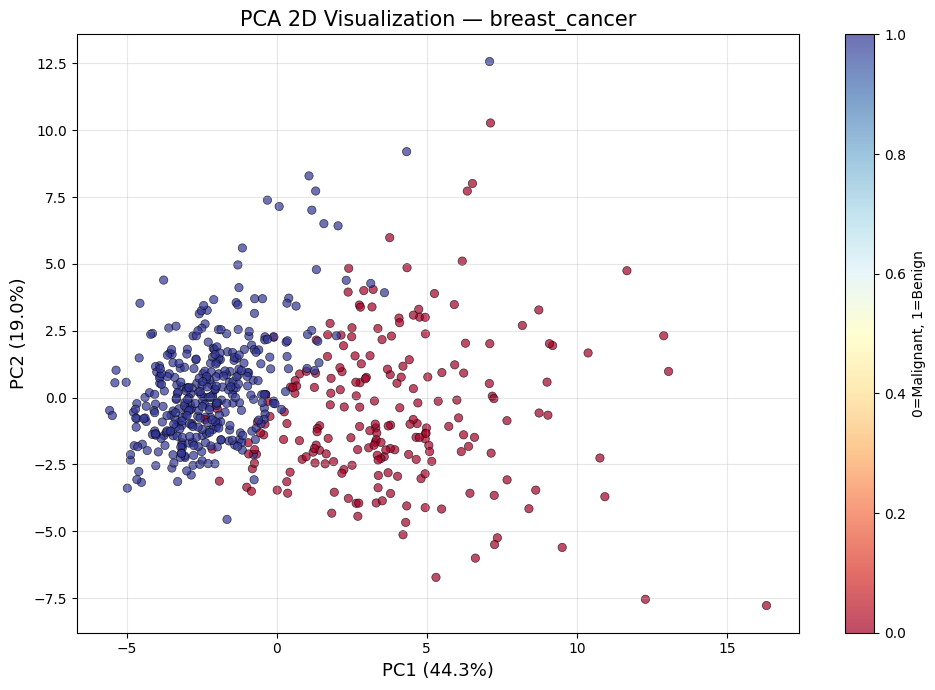

In [10]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=y, cmap="RdYlBu", alpha=0.7,
    edgecolors="k", linewidth=0.5,
)
plt.xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=13
)
plt.ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=13
)
plt.title("PCA 2D Visualization — breast_cancer", fontsize=15)
plt.colorbar(scatter, label="0=Malignant, 1=Benign")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## Step 11. 피처 2개 선택 vs. PCA 2차원 — 비교

PCA의 가치를 직접 비교로 체감한다

| 방법 | x축 | y축 | 정보 |
|------|-----|-----|------|
| 피처 2개 선택 | mean radius | mean texture | 나머지 28개 **완전 손실** |
| PCA 2차원 | PC1 (44%) | PC2 (19%) | 30개 피처 **골고루 반영** |

→ 같은 데이터인데 PCA가 「가장 정보가 많은 시점」을 찾아준 것

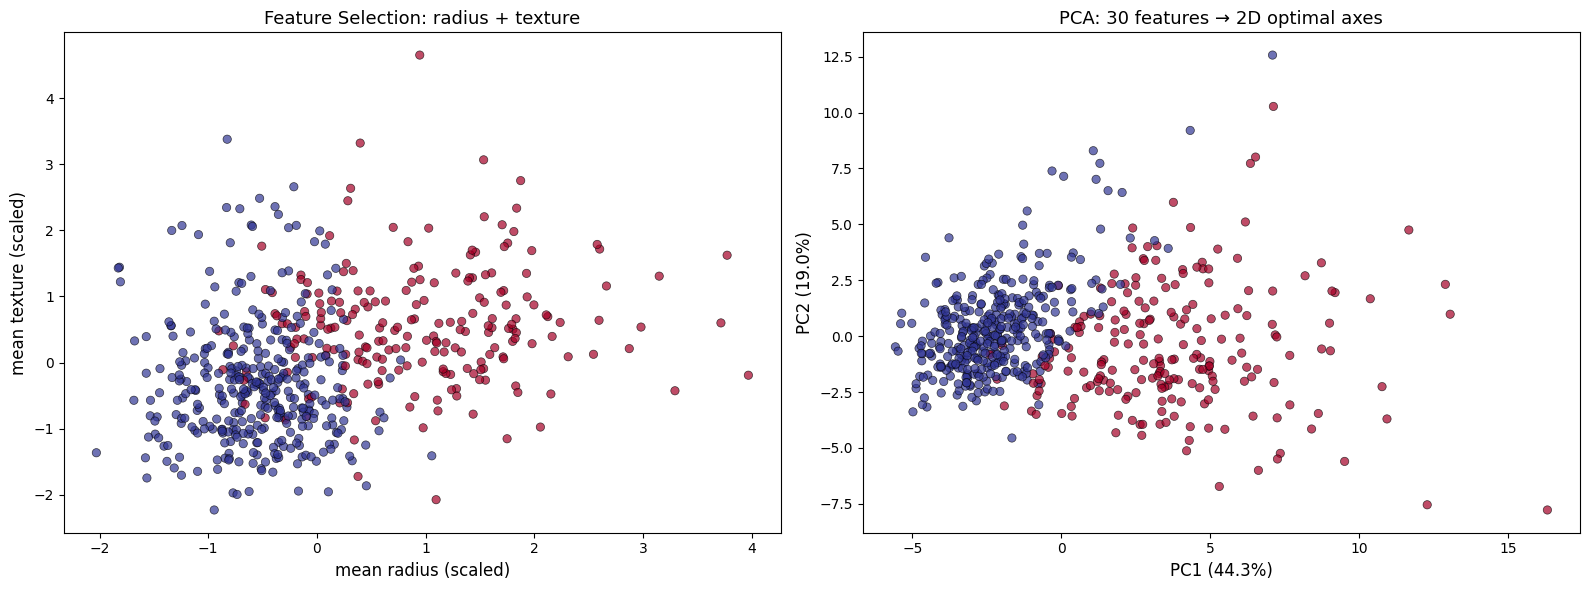

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 원래 피처 2개로 산점도
axes[0].scatter(
    X_scaled[:, 0], X_scaled[:, 1],
    c=y, cmap="RdYlBu", alpha=0.7,
    edgecolors="k", linewidth=0.5,
)
axes[0].set_xlabel("mean radius (scaled)", fontsize=12)
axes[0].set_ylabel("mean texture (scaled)", fontsize=12)
axes[0].set_title("Feature Selection: radius + texture", fontsize=13)

# 오른쪽: PCA 2차원 산점도
axes[1].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=y, cmap="RdYlBu", alpha=0.7,
    edgecolors="k", linewidth=0.5,
)
axes[1].set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=12
)
axes[1].set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=12
)
axes[1].set_title("PCA: 30 features → 2D optimal axes", fontsize=13)

plt.tight_layout()
plt.show()

---
## Step 12. K-Means + PCA 결합 — 두 비지도학습 도구의 만남

11주차 K-Means(K=2) 결과를 PCA 2차원에 표시한다

| 도구 | 역할 |
|------|------|
| K-Means | 「이 데이터에 2개 그룹이 있다」 — X만 보고 그룹 **발견** |
| PCA | 「30차원을 2차원으로 줄여 보여준다」 — 발견한 구조를 **시각화** |
| 결합 | 발견 + 시각화 = 「정답 없이 패턴을 발견하고 눈으로 확인」 |

**왼쪽: 실제 레이블(정답) / 오른쪽: K-Means가 발견한 구조**
→ 두 그래프가 유사하면 비지도학습이 실제 구조를 발견한 증거

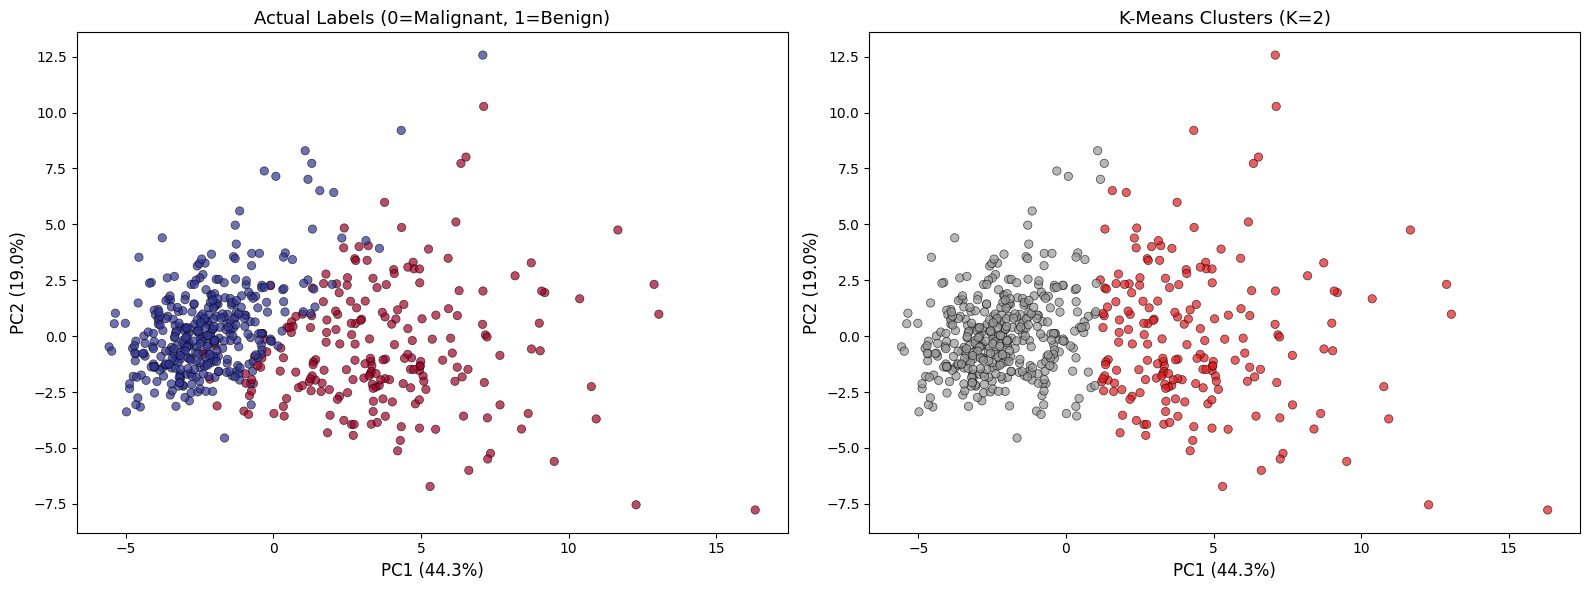

In [12]:
# 11주차 K-Means (K=2) 재실행
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 실제 레이블
axes[0].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=y,
    cmap="RdYlBu", alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[0].set_title("Actual Labels (0=Malignant, 1=Benign)", fontsize=13)
axes[0].set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=12
)
axes[0].set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=12
)

# 오른쪽: K-Means 클러스터
axes[1].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=cluster_labels,
    cmap="Set1", alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[1].set_title("K-Means Clusters (K=2)", fontsize=13)
axes[1].set_xlabel(
    f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.1f}%)", fontsize=12
)
axes[1].set_ylabel(
    f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.1f}%)", fontsize=12
)

plt.tight_layout()
plt.show()

---
## Step 13. 보충 — PC1 가중치 확인 + 스케일링 효과 비교

### PC1이 담고 있는 것
- `pca_2d.components_[0]`: PC1의 가중치 (30개 피처 각각의 기여도)
- 가중치 큰 피처 = radius, perimeter, area, concavity → 「종양 크기·복잡도 종합 지표」

**⚠ 이것은 대략적 해석 — 주성분이 항상 명확한 의미를 갖지는 않는다**

### 스케일링 없이 PCA를 하면?
- 스케일링 O → PC1: ~44% (30개 피처 골고루 반영)
- 스케일링 X → PC1: ~98% (area 하나가 지배!)

→ 스케일링 없으면 PCA가 피처 조합이 아닌 **피처 선택**이 되어버림

In [13]:
# PC1 가중치 (절대값 상위 10개)
pc1_weights = pca_2d.components_[0]
sorted_indices = np.argsort(np.abs(pc1_weights))[::-1]

print("=== PC1 가중치 — 절대값 상위 10개 ===")
print(f"{'피처':<25} {'가중치':>10}")
print("-" * 38)
for i in range(10):
    idx = sorted_indices[i]
    print(f"  {feature_names[idx]:<25} {pc1_weights[idx]:>+.4f}")

print()
print("→ radius, perimeter, area, concavity — 모두 종양 크기·형태 피처")
print("→ PC1 ≈ 종양 크기·복잡도 종합 지표 (대략적 해석)")

=== PC1 가중치 — 절대값 상위 10개 ===
피처                               가중치
--------------------------------------
  mean concave points       +0.2609
  mean concavity            +0.2584
  worst concave points      +0.2509
  mean compactness          +0.2393
  worst perimeter           +0.2366
  worst concavity           +0.2288
  worst radius              +0.2280
  mean perimeter            +0.2275
  worst area                +0.2249
  mean area                 +0.2210

→ radius, perimeter, area, concavity — 모두 종양 크기·형태 피처
→ PC1 ≈ 종양 크기·복잡도 종합 지표 (대략적 해석)


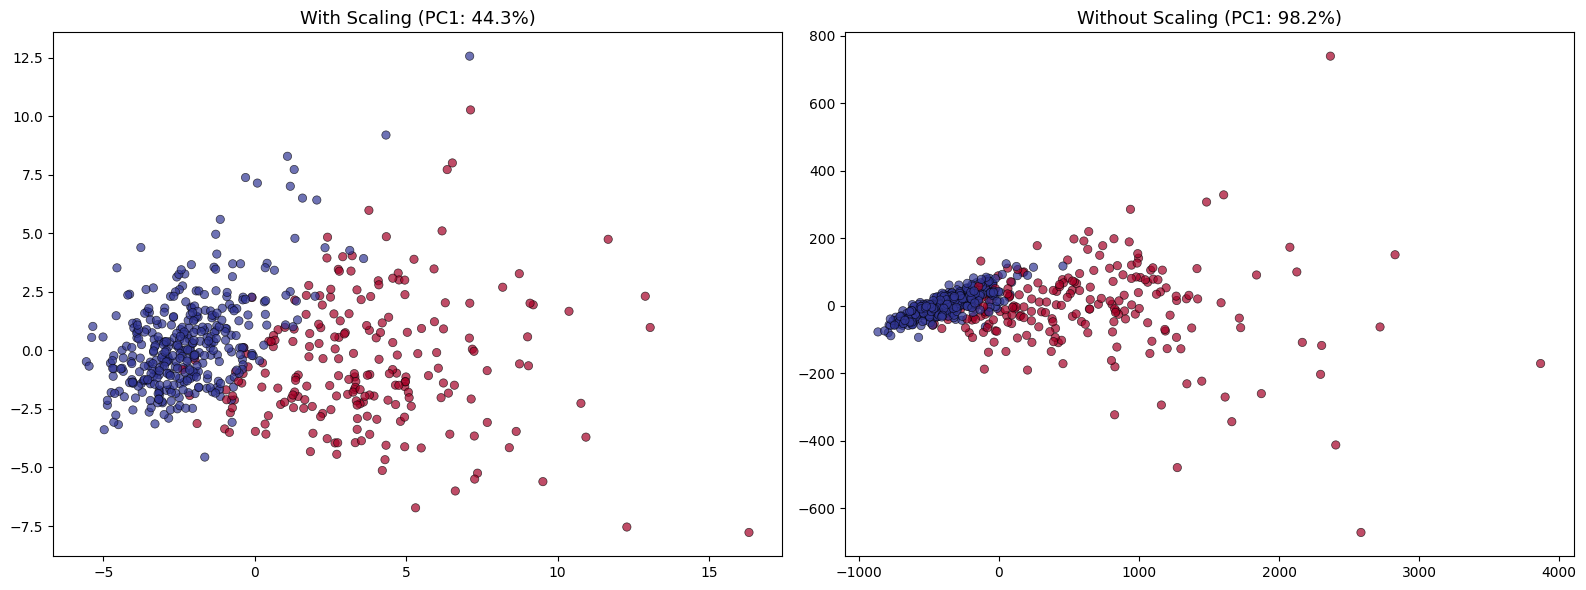

스케일링 O → PC1: 44.3%  (30개 피처 골고루 반영)
스케일링 X → PC1: 98.2%  (area 하나가 지배!)

→ 비지도학습 공통 원칙: StandardScaler는 항상 먼저!


In [14]:
# 스케일링 없이 PCA (비교 목적)
pca_noscale = PCA(n_components=2)
X_pca_noscale = pca_noscale.fit_transform(X)   # ← 원본 X!

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="RdYlBu",
    alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[0].set_title(
    f"With Scaling (PC1: {pca_2d.explained_variance_ratio_[0] * 100:.1f}%)",
    fontsize=13,
)

axes[1].scatter(
    X_pca_noscale[:, 0], X_pca_noscale[:, 1], c=y, cmap="RdYlBu",
    alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[1].set_title(
    f"Without Scaling (PC1: "
    f"{pca_noscale.explained_variance_ratio_[0] * 100:.1f}%)",
    fontsize=13,
)

plt.tight_layout()
plt.show()

print(
    f"스케일링 O → PC1: "
    f"{pca_2d.explained_variance_ratio_[0] * 100:.1f}%"
    f"  (30개 피처 골고루 반영)"
)
print(
    f"스케일링 X → PC1: "
    f"{pca_noscale.explained_variance_ratio_[0] * 100:.1f}%"
    f"  (area 하나가 지배!)"
)
print()
print("→ 비지도학습 공통 원칙: StandardScaler는 항상 먼저!")

---
## Step 14. Pipeline 구성 — PCA + 지도학습 결합 (차시 3)

PCA는 비지도학습이지만 **지도학습의 전처리**로도 사용 가능

### PCA를 지도학습에 결합하는 이유
| 이유 | 설명 |
|------|------|
| 노이즈 제거 | 분산 작은 주성분(노이즈) 제거 → 과적합↓ (5주차) |
| 다중공선성 해소 | radius·perimeter·area 상관↑ → 주성분끼리 직교 → 안정성↑ |
| 계산 효율 | 30→7 주성분 → 학습 속도↑ (피처 수천 개일 때 큰 차이) |

### Pipeline에 넣는 이유 — 데이터 누수 방지
| 잘못된 방법 | 올바른 방법 |
|------------|------------|
| Pipeline **바깥**에서 scaler·PCA | Pipeline **안**에 scaler·PCA |
| 전체 데이터에 fit → 테스트 정보 누수 | 각 폴드 훈련 데이터에만 fit |

→ **핵심 규칙**: 전처리(Scaler, PCA) + 모델 → 항상 Pipeline 안에 함께 (10주차 원칙)

In [15]:
# (A) PCA 없음: 기준선 (Baseline)
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  LogisticRegression(max_iter=10000, random_state=42)),
])

# (B) PCA(n=7): 30→7, 누적 분산 ~91%
pipe_pca_7 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=7)),
    ("model",  LogisticRegression(max_iter=10000, random_state=42)),
])

# (C) PCA(n=2): 30→2, 누적 분산 ~63%
pipe_pca_2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=2)),
    ("model",  LogisticRegression(max_iter=10000, random_state=42)),
])

print("Pipeline 3개 구성 완료")
print("  (A) Scaler → LogisticRegression             (PCA 없음, 30피처)")
print("  (B) Scaler → PCA(7) → LogisticRegression    (~91% 보존)")
print("  (C) Scaler → PCA(2) → LogisticRegression    (~63% 보존)")
print()
print("→ PCA 자체는 y 없이 작동, 최종 LogisticRegression이 y 사용")
print("→ Pipeline 안에 넣어야 각 폴드에서 올바르게 fit·transform")

Pipeline 3개 구성 완료
  (A) Scaler → LogisticRegression             (PCA 없음, 30피처)
  (B) Scaler → PCA(7) → LogisticRegression    (~91% 보존)
  (C) Scaler → PCA(2) → LogisticRegression    (~63% 보존)

→ PCA 자체는 y 없이 작동, 최종 LogisticRegression이 y 사용
→ Pipeline 안에 넣어야 각 폴드에서 올바르게 fit·transform


---
## Step 15. 교차검증 성능 비교 — PCA 전후

**「PCA를 쓰면 항상 성능이 좋아지는가?」** — 실험으로 답한다

### 기대 vs 실제
| 예상 | 실제 |
|------|------|
| PCA로 노이즈 제거 → 성능↑? | 이 데이터에서는 성능↓ |

### 왜?
| 원인 | 설명 |
|------|------|
| 이 데이터의 특성 | 30개 피처가 이미 잘 구성 → 노이즈 피처 적음 → PCA 효과 미미 |
| PCA의 한계 | PCA는 y를 모름 → 분산 작지만 분류에 중요한 피처를 버릴 수 있음 |

**⚠ PCA를 쓸지 말지는 실험으로 확인 — 맹목적 적용 금지. 교차검증이 판단의 근거**

In [16]:
results = {}

scores_a = cross_val_score(pipe_no_pca, X, y, cv=5, scoring="accuracy")
results["(A) PCA 없음 (30피처)"] = scores_a

scores_b = cross_val_score(pipe_pca_7, X, y, cv=5, scoring="accuracy")
results["(B) PCA(n=7)        "] = scores_b

scores_c = cross_val_score(pipe_pca_2, X, y, cv=5, scoring="accuracy")
results["(C) PCA(n=2)        "] = scores_c

print("=== 5-Fold 교차검증 결과 (Accuracy) ===")
print("=" * 55)
for name, scores in results.items():
    print(f"  {name}  평균: {scores.mean():.4f}  (±{scores.std():.4f})")
print("=" * 55)
print()
print("→ PCA 없음이 가장 높음!")
print("→ 「PCA를 쓰면 항상 좋아진다」는 오해가 교정됨")
print("→ 이 데이터는 30피처가 이미 잘 구성 — PCA 노이즈 제거 효과 미미")

=== 5-Fold 교차검증 결과 (Accuracy) ===
  (A) PCA 없음 (30피처)  평균: 0.9807  (±0.0065)
  (B) PCA(n=7)          평균: 0.9719  (±0.0086)
  (C) PCA(n=2)          평균: 0.9508  (±0.0162)

→ PCA 없음이 가장 높음!
→ 「PCA를 쓰면 항상 좋아진다」는 오해가 교정됨
→ 이 데이터는 30피처가 이미 잘 구성 — PCA 노이즈 제거 효과 미미


---
## Step 16. 주성분 수에 따른 성능 변화 그래프

n_components를 1~30으로 바꿔가며 성능 변화를 확인한다

### 기대 패턴
| 구간 | 성능 | 의미 |
|------|------|------|
| n=1~7 | 점점 상승 | 주성분 추가 → 정보 증가 |
| n=7~30 | 거의 수평 | 추가해도 성능 변화 미미 |

→ n=7이면 차원 77% 감소하면서 성능 약 0.5%만 손해 — 「적은 차원으로 비슷한 성능」

n_components     Accuracy
----------------------------
  1                0.9157
  2                0.9508
  3                0.9456
  5                0.9702
  7                0.9719
  10               0.9807
  15               0.9772
  20               0.9772
  25               0.9807
  30               0.9807  ← No PCA


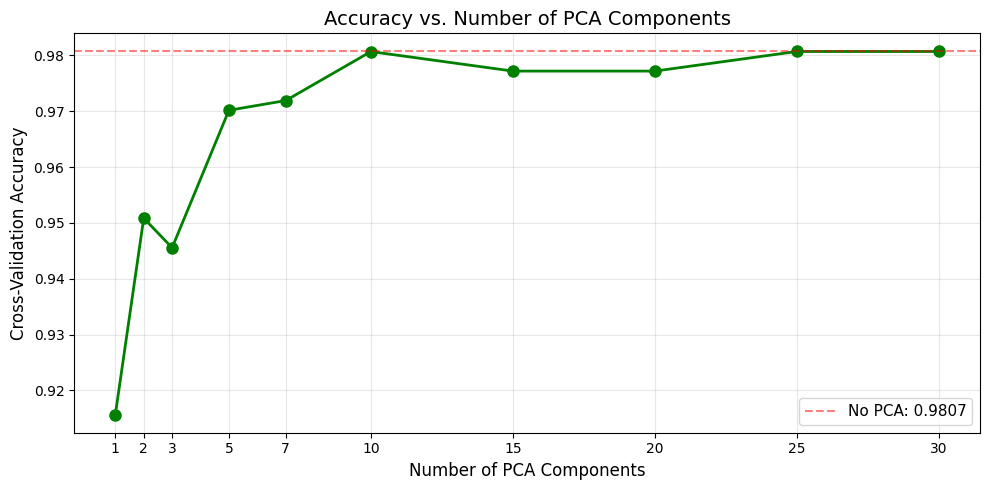

In [17]:
n_components_range = [1, 2, 3, 5, 7, 10, 15, 20, 25, 30]
mean_scores = []

print(f"{'n_components':<14} {'Accuracy':>10}")
print("-" * 28)

for n in n_components_range:
    if n == 30:
        pipe = pipe_no_pca
    else:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca",    PCA(n_components=n)),
            ("model",  LogisticRegression(max_iter=10000, random_state=42)),
        ])
    scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
    mean_scores.append(scores.mean())
    marker = "  ← No PCA" if n == 30 else ""
    print(f"  {n:<12d} {scores.mean():>10.4f}{marker}")

plt.figure(figsize=(10, 5))
plt.plot(n_components_range, mean_scores, "go-", linewidth=2, markersize=8)
plt.axhline(
    y=mean_scores[-1], color="red", linestyle="--", alpha=0.5,
    label=f"No PCA: {mean_scores[-1]:.4f}",
)
plt.xlabel("Number of PCA Components", fontsize=12)
plt.ylabel("Cross-Validation Accuracy", fontsize=12)
plt.title("Accuracy vs. Number of PCA Components", fontsize=14)
plt.xticks(n_components_range)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

---
## Step 17. PCA 후 K-Means vs. 원본 K-Means — 클러스터링 결합 비교

K-Means와 PCA를 결합하는 **두 가지 방향**

| 방향 | 순서 | 목적 |
|------|------|------|
| 방향 1 | K-Means 먼저 → PCA 시각화 | Step 12에서 한 것 — 발견 → 시각화 |
| 방향 2 | PCA 먼저 → K-Means | 차원의 저주 완화, 노이즈 제거 후 클러스터링 |

→ 어느 순서가 좋은가? — 데이터와 목적에 따라 다름 → **항상 실험으로 확인**

In [18]:
# (A) 원본 30차원에서 K-Means
kmeans_original = KMeans(n_clusters=2, random_state=42)
labels_original = kmeans_original.fit_predict(X_scaled)

# (B) PCA(7) 후 K-Means
pca_7 = PCA(n_components=7)
X_pca_7 = pca_7.fit_transform(X_scaled)
kmeans_pca = KMeans(n_clusters=2, random_state=42)
labels_pca = kmeans_pca.fit_predict(X_pca_7)

# 실루엣 점수 비교
sil_original = silhouette_score(X_scaled, labels_original)
sil_pca = silhouette_score(X_pca_7, labels_pca)

print("=== K-Means (K=2) 비교 ===")
print("=" * 50)
print(f"  (A) 원본 30차원:  실루엣 = {sil_original:.4f}")
print(f"  (B) PCA(7) 후:    실루엣 = {sil_pca:.4f}")
print(f"  차이: {abs(sil_original - sil_pca):.4f}")
print("=" * 50)
print()
print("→ 이 데이터에서는 차이 미미 — 30피처가 이미 잘 구성")
print("→ 피처 수백 개 + 노이즈 많으면 PCA 먼저 → 품질 향상 가능")

=== K-Means (K=2) 비교 ===
  (A) 원본 30차원:  실루엣 = 0.3447
  (B) PCA(7) 후:    실루엣 = 0.3708
  차이: 0.0261

→ 이 데이터에서는 차이 미미 — 30피처가 이미 잘 구성
→ 피처 수백 개 + 노이즈 많으면 PCA 먼저 → 품질 향상 가능


---
## Step 18. 결합 시각화 — 실제 레이블 vs. 두 방향 비교
- **왼쪽**: 실제 레이블 (정답)
- **가운데**: 방향 1 — 원본 30차원에서 K-Means → PCA로 시각화
- **오른쪽**: 방향 2 — PCA(7) 먼저 → K-Means

→ 세 그래프를 나란히 비교하여 비지도학습이 발견한 구조를 눈으로 확인

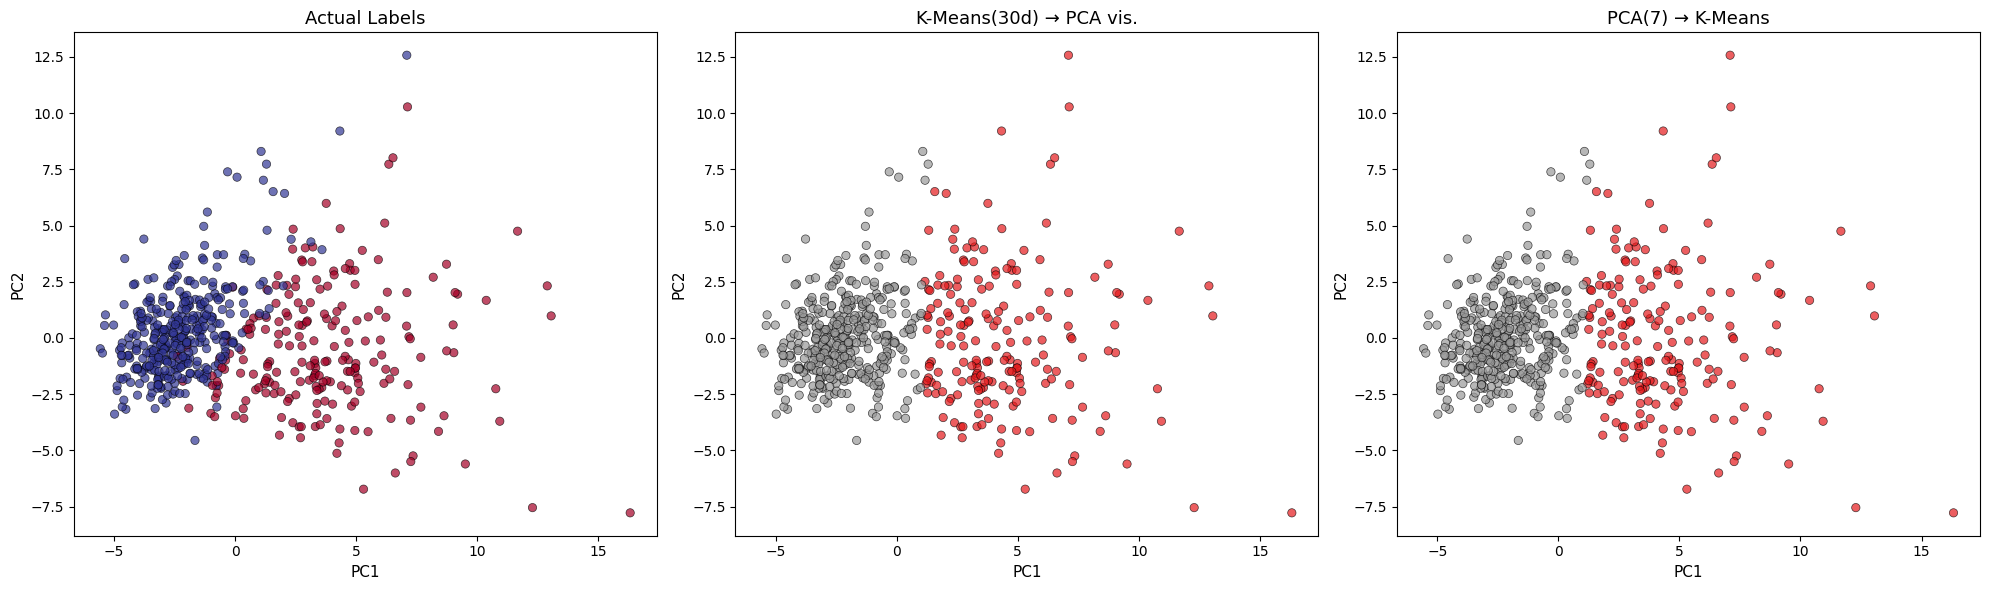

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# (1) 실제 레이블
axes[0].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=y,
    cmap="RdYlBu", alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[0].set_title("Actual Labels", fontsize=13)
axes[0].set_xlabel("PC1", fontsize=11)
axes[0].set_ylabel("PC2", fontsize=11)

# (2) 방향 1: 원본 K-Means → PCA 시각화
axes[1].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_original,
    cmap="Set1", alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[1].set_title("K-Means(30d) → PCA vis.", fontsize=13)
axes[1].set_xlabel("PC1", fontsize=11)
axes[1].set_ylabel("PC2", fontsize=11)

# (3) 방향 2: PCA 먼저 → K-Means
axes[2].scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_pca,
    cmap="Set1", alpha=0.7, edgecolors="k", linewidth=0.5,
)
axes[2].set_title("PCA(7) → K-Means", fontsize=13)
axes[2].set_xlabel("PC1", fontsize=11)
axes[2].set_ylabel("PC2", fontsize=11)

plt.tight_layout()
plt.show()

In [20]:
print("=" * 60)
print("12주차 PCA(주성분 분석) 실습 완료")
print("=" * 60)
print()
print("핵심 정리:")
print("  1. PCA는 분산을 최대화하는 새로운 축을 찾는다")
print("  2. PCA ≠ 피처 선택 — 피처를 조합하여 새 축 생성")
print("  3. 스케일링 필수 — 분산 기반이므로 StandardScaler 먼저")
print("  4. 주성분 수 선택은 정답이 아니라 판단")
print("  5. PCA가 항상 성능을 올리지는 않는다 — 실험으로 확인")
print()
print("⚠ 비지도학습 공통 원칙:")
print("  y 없음 / 스케일링 필수 / 정답 없음 / 지도학습 결합 가능")
print("  모든 선택은 실험과 판단으로 확인한다.")

12주차 PCA(주성분 분석) 실습 완료

핵심 정리:
  1. PCA는 분산을 최대화하는 새로운 축을 찾는다
  2. PCA ≠ 피처 선택 — 피처를 조합하여 새 축 생성
  3. 스케일링 필수 — 분산 기반이므로 StandardScaler 먼저
  4. 주성분 수 선택은 정답이 아니라 판단
  5. PCA가 항상 성능을 올리지는 않는다 — 실험으로 확인

⚠ 비지도학습 공통 원칙:
  y 없음 / 스케일링 필수 / 정답 없음 / 지도학습 결합 가능
  모든 선택은 실험과 판단으로 확인한다.
